# Notebook 01 — EDA & Data Preparation

**Module:** ITI113 Machine Learning & Operations  
**Focus Area:** A — Data & EDA  
**Estimated Runtime:** 5–8 minutes on `ml.t3.medium`

## What this notebook does

1. Downloads the dataset and uploads it to S3
2. Exploratory Data Analysis — distributions, missing values, class balance
3. Feature engineering
4. Chronological split and StandardScaler
5. Saves four processed CSVs to S3 for Notebook 02 and the pipeline
## Prerequisites

- SageMaker Studio, kernel **Python 3 (Data Science 3.0)**, instance `ml.t3.medium`
- SageMaker execution role has S3 read/write on the default bucket


## Install required packages

In [1]:
# After running, restart the kernel before continuing.
%pip -q install --upgrade "sagemaker>=2,<3" boto3 botocore
%pip -q install "scikit-learn==1.4.2" kagglehub

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
aiobotocore 3.8.0 requires botocore<1.43.47,>=1.43.3, but you have botocore 1.43.81 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.6.0 which is incompatible.
sagemaker-mlops 1.12.0 requires sagemaker-core>=2.12.0, but you have sagemaker-core 1.0.78 which is

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.6.0 which is incompatible.
sagemaker-serve 1.12.0 requires sagemaker-core>=2.12.0, but you have sagemaker-core 1.0.78 which is incompatible.
sagemaker-train 1.14.0 requires sagemaker-core>=2.14.0, but you have sagemaker-core 1.0.78 which is incompatible.


Note: you may need to restart the kernel to use updated packages.


## Install Required Libraries

In [2]:
# Standard Library Imports
import os

# 1. Suppress the SageMaker v2 deprecation warning
os.environ["SAGEMAKER_SUPPRESS_V2_WARNING"] = "1"

# Standard Library Imports
import gc
import json
import resource
import shutil
import tempfile

from pathlib import Path


# Data & ML Libraries
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Cloud & MLOps
import boto3


# AWS SageMaker SDK
import sagemaker


# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

print(f"SageMaker Version: {sagemaker.__version__}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


SageMaker Version: 2.257.6


The same `current_memory_mb()`/`log_memory()` observability helpers reused across all four notebooks in this series — logging memory right after imports (438 MB baseline) gives a reference point for how much the 1M-row raw CSV load adds later.

`current_memory_mb()` / `log_memory()` are lightweight observability helpers (peak RSS via `resource.getrusage`) rather than anything ML-specific — useful for confirming the chunked S3 read below doesn't blow up notebook memory on a 1M-row CSV.

In [3]:
# Common function for memory usage observability
def current_memory_mb():
    """Peak resident memory of this process so far, in MB (Linux)."""
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024


def log_memory(label):
    print(f"[memory] {label}: {current_memory_mb():,.0f} MB (process peak RSS)")


log_memory("after imports")

[memory] after imports: 438 MB (process peak RSS)


## Configuration

Establishes the shared `TEAM_ID`/`STUDENT_ID`/`BUCKET`/`PREFIX` convention that every downstream notebook (02, 03, 04) reads from — this is the root of the entire pipeline's S3 layout (`iti113/team09/data/bank-fraud-detection/...`).

In [4]:
# Cloud configuration
session = sagemaker.Session()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
s3_client = boto3.client("s3")

TEAM_ID = "team09"
STUDENT_ID = "s901"
PROJECT_NAME = "bank-fraud-detection"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

print(f"Bucket     : {BUCKET}")
print(f"Prefix     : {PREFIX}")
print(f"Region     : {region}")
print(f"Role       : {role.split('/')[-1]}")
print(f"Team ID    : {TEAM_ID}")
print(f"Student ID : {STUDENT_ID}")

Bucket     : nyp-26s1-iti113
Prefix     : iti113/team09/data/bank-fraud-detection
Region     : ap-southeast-1
Role       : SageMakerExecutionRole-ITI113-Team09
Team ID    : team09
Student ID : s901


`CHUNK_SIZE=200_000` and `PLOT_SAMPLE_SIZE=100_000` are set here once and reused throughout — the chunked-read approach (for memory) and the sampled-plotting approach (for speed) are both defined by these two constants.

In [5]:
# Local configuration
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
TEST_SIZE = 0.2

LOCAL_DATASET_DIR = "./dataset"
RAW_DATASET_DIR = f"{LOCAL_DATASET_DIR}/raw"

TARGET_COLUMN = "is_fraud"

CHUNK_SIZE = 200_000
PLOT_SAMPLE_SIZE = 100_000

print(f"LOCAL_DATASET_DIR : {LOCAL_DATASET_DIR}")
print(f"RAW_DATASET_DIR   : {RAW_DATASET_DIR}")
print(f"RANDOM_STATE      : {RANDOM_STATE}")
print(f"CHUNK_SIZE        : {CHUNK_SIZE}")
print(f"PLOT_SAMPLE_SIZE  : {PLOT_SAMPLE_SIZE}")

LOCAL_DATASET_DIR : ./dataset
RAW_DATASET_DIR   : ./dataset/raw
RANDOM_STATE      : 42
CHUNK_SIZE        : 200000
PLOT_SAMPLE_SIZE  : 100000


Downloads the raw Kaggle dataset (`nafiulislam490/bank-transaction-fraud-detection-dataset`) only if it isn't already cached locally — a sensible idempotency check so repeated notebook runs (e.g., after a kernel restart) don't re-trigger an unnecessary Kaggle auth + download.

In [6]:
# Check if the dataset exists and download if empty
if os.path.exists(RAW_DATASET_DIR) and os.listdir(RAW_DATASET_DIR):
    print(f"Dataset already exists at '{RAW_DATASET_DIR}'. Skipping download.")
else:
    # 1. Download dataset from Kaggle
    kagglehub.login()
    DATASET_HANDLE = "nafiuslam490/bank-transaction-fraud-detection-dataset"
    raw_download_path = kagglehub.dataset_download(DATASET_HANDLE)
    print(f"Downloaded by kagglehub to: {raw_download_path}")

    # 2. Ensure target local directory is clean before copying
    if os.path.exists(RAW_DATASET_DIR):
        shutil.rmtree(RAW_DATASET_DIR)

    # 3. Copy the contents of the download path into local target dir
    shutil.copytree(raw_download_path, RAW_DATASET_DIR)
    print(f"Files copied to local directory: {RAW_DATASET_DIR}")


Dataset already exists at './dataset/raw'. Skipping download.


### 1.1 Downcasting helper

Since the dataset size is large (1M rows), generic helper is created to shrink a dataframe's memory footprint without changing its values:
- Integer / float columns are downcast to the smallest dtype that can hold their range
  (e.g. `int64` → `int8`/`int16`, `float64` → `float32`).
- Low-cardinality `object` (string) columns are converted to `category`, which stores each
  unique value once plus a small integer code per row instead of a full Python string per row.

**Per chunk while reading** is applied so that pandas never has to hold the full-size,
un-downcast 1M-row frame in memory at any point.

In [7]:
def reduce_memory(df, category_threshold=0.5, verbose=False):
    """Downcast numeric columns and convert low-cardinality strings to category, in place."""
    start_mem = df.memory_usage(deep=True).sum() / 1024**2 if verbose else None

    for col in df.columns:
        col_dtype = df[col].dtype

        if col_dtype == "object" or str(col_dtype) == "str":
            n_unique = df[col].nunique(dropna=True)
            n_total = len(df[col])
            if n_total > 0 and (n_unique / n_total) < category_threshold:
                df[col] = df[col].astype("category")
        elif pd.api.types.is_integer_dtype(col_dtype):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(col_dtype):
            if df[col].abs().max() < np.finfo(np.float32).max:
                df[col] = df[col].astype("float32")
    if verbose:
        end_mem = df.memory_usage(deep=True).sum() / 1024**2
        pct = 100 * (start_mem - end_mem) / start_mem if start_mem else 0
        print(f"Memory: {start_mem:.1f} MB -> {end_mem:,.1f} MB ({pct:.1f}% reduction)")
    return df


# Columns kept as plain strings (either high-cardinality IDs, or parsed to datetime later)
DTYPE_HINTS = {
    "transaction_id": "string",
    "customer_id": "string",
    "transaction_date": "string",
    "transaction_time": "string",
}

In [8]:
# Load dataset
# Dataset is loaded in chunks, each chunk is downcasted before concatenating.
# This keeps peak memory well below "full cvs parsed as object dtypes" at any point
# and the final concanated frame compact
csv_path = os.path.join(RAW_DATASET_DIR, "bank_fraud.csv")

log_memory("before loading dataset")

chunks = []
for chunk in pd.read_csv(csv_path, dtype=DTYPE_HINTS, chunksize=CHUNK_SIZE):
    reduce_memory(chunk)
    chunks.append(chunk)

df_raw = pd.concat(chunks, ignore_index=True)

del chunks
gc.collect()

log_memory("after loading dataset + downcasting dataset")

print(df_raw.shape)
print(f"Target : {df_raw[TARGET_COLUMN].value_counts().to_dict()}")
df_raw.info(memory_usage="deep")
df_raw.head()

[memory] before loading dataset: 438 MB (process peak RSS)


[memory] after loading dataset + downcasting dataset: 708 MB (process peak RSS)
(1000000, 26)
Target : {0: 944745, 1: 55255}


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype   
---  ------                    --------------    -----   
 0   transaction_id            1000000 non-null  string  
 1   customer_id               1000000 non-null  string  
 2   transaction_date          1000000 non-null  string  
 3   transaction_time          1000000 non-null  string  
 4   hour_of_day               1000000 non-null  int8    
 5   is_weekend                1000000 non-null  int8    
 6   is_night_transaction      1000000 non-null  int8    
 7   country                   1000000 non-null  category
 8   city                      1000000 non-null  category
 9   merchant_category         1000000 non-null  category
 10  payment_method            1000000 non-null  category
 11  device_type               1000000 non-null  category
 12  customer_age              1000000 non-null  int8    
 13  credit_score 

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.490002,157,23,52.700001,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.710007,153,23,0.900000,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.199997,161,20,9.200000,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,176.259995,160,25,56.900002,7.95,0,7,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.740000,134,18,38.900002,2.16,0,0,0,0,NaN


**Finding — first look at the raw data confirms the core class-imbalance challenge:** 1,000,000 rows × 26 columns, target split **944,745 non-fraud vs. 55,255 fraud (5.53% fraud rate)**. This ~17:1 imbalance is the single biggest factor shaping every downstream modeling decision in Notebooks 02–04 (threshold tuning, PR-AUC over accuracy, etc.) — worth remembering this is the *source* of that pattern, not something introduced later. Memory grew from 438 MB → 707 MB after loading + downcasting the full 1M-row frame, which is a good outcome for a dataset that would be considerably larger if read as plain `object`/`float64` dtypes throughout.

Uploads the *raw*, unmodified dataset to S3 (`raw/bank_fraud.csv`) before any feature engineering — this preserves a clean, versioned copy of the original data independent of whatever transformations happen later in this notebook, which is good practice for reproducibility/auditability.

In [9]:
# Upload raw dataset to S3 for version control
# Stream from a temp file on disk instead of building a full csv string in memmory
# avoid using io.StringIO() approach which doubles memory
tmp_raw_path = "/tmp/bank_fraud_raw.csv"
df_raw.to_csv(tmp_raw_path, index=False)

key_raw = f"{PREFIX}/raw/bank_fraud.csv"
s3_client.upload_file(tmp_raw_path, BUCKET, key_raw)
RAW_S3_URI = f"s3://{BUCKET}/{key_raw}"
print(f"Raw data uploaded to: {RAW_S3_URI}")

os.remove(tmp_raw_path)
log_memory("after S3 upload")

Raw data uploaded to: s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/raw/bank_fraud.csv
[memory] after S3 upload: 708 MB (process peak RSS)


## 2. Exploratory Data Analysis

In [10]:
NUMERIC_FEATURES = [
    "hour_of_day",
    "customer_age",
    "credit_score",
    "account_age_years",
    "account_balance",
    "transaction_amount",
    "num_prev_transactions",
    "transaction_freq_monthly",
    "distance_from_home_km",
    "time_since_last_txn_hrs",
    "failed_attempts",
]
CATEGORICAL_FEATURES = [
    "is_weekend",
    "is_night_transaction",
    "country",
    "city",
    "merchant_category",
    "payment_method",
    "device_type",
    "is_international",
    "pin_changed_recently",
]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES


DROP_COLS = [
    "transaction_id",
    "customer_id",
    "transaction_date",
    "transaction_time",
    "fraud_type",
]

print(f"Numerical features  : {NUMERIC_FEATURES}")
print(f"Categorical features  : {CATEGORICAL_FEATURES}")
print(f"Drop columns  : {DROP_COLS}")

Numerical features  : ['hour_of_day', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'failed_attempts']
Categorical features  : ['is_weekend', 'is_night_transaction', 'country', 'city', 'merchant_category', 'payment_method', 'device_type', 'is_international', 'pin_changed_recently']
Drop columns  : ['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'fraud_type']


In [11]:
# Returns unique values of columns which need bias check later
cols = ['country', 'city', 'merchant_category', 'device_type', 'payment_method']

for col in cols:
    list = df_raw[col].unique()
    print(f"--- Unique values in {col} (total={len(list)})---")
    print(sorted(list))
    print()

--- Unique values in country (total=10)---
['Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Japan', 'Mexico', 'UK', 'USA']

--- Unique values in city (total=20)---
['Berlin', 'Delhi', 'Guadalajara', 'London', 'Los Angeles', 'Lyon', 'Manchester', 'Melbourne', 'Mexico City', 'Mumbai', 'Munich', 'New York', 'Osaka', 'Paris', 'Rio', 'Sydney', 'São Paulo', 'Tokyo', 'Toronto', 'Vancouver']

--- Unique values in merchant_category (total=15)---
['ATM Withdrawal', 'Clothing', 'Crypto Exchange', 'Education', 'Electronics', 'Entertainment', 'Fuel', 'Gaming', 'Grocery', 'Healthcare', 'Jewelry', 'Online Shopping', 'Restaurant', 'Travel', 'Utilities']



--- Unique values in device_type (total=5)---
['ATM', 'Desktop', 'Mobile', 'POS Terminal', 'Tablet']

--- Unique values in payment_method (total=6)---
['Bank Transfer', 'Cheque', 'Credit Card', 'Crypto', 'Debit Card', 'Mobile Payment']



**Finding — categorical cardinality is deliberately modest and geography looks synthetic/balanced-by-design:** 10 countries, 20 cities, 15 merchant categories, 5 device types, 6 payment methods — small enough for one-hot encoding to stay tractable (no high-cardinality target encoding needed). Printing these upfront as a "bias check" is a good habit: it lets us visually confirm there's no unexpected category (typos, `NaN`-as-string, single-country dominance) before those columns are used to compute fraud rates by group further down.

In [12]:
print(df_raw.columns)

Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_time',
       'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city',
       'merchant_category', 'payment_method', 'device_type', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud', 'fraud_type'],
      dtype='object')


Full column inventory (26 columns) — useful as a quick reference while reading the feature-engineering cells further down, especially for spotting which raw columns (`transaction_date`, `transaction_time`, `fraud_type`) get consumed / dropped rather than used directly as model features.

In [13]:
# Missing values
missing = df_raw.isnull().sum()
duplicated = df_raw.duplicated().sum()

print("Missing values:")
print(missing[missing > 0])
print(f"\nTotal missing: {missing.sum()}")
print("Note: only `fraud_type` is missing for non-fraud rows.")
print("This column is target-derived and will be dropped.")

print("\nDuplicated values:")
print(f"Total duplicated: {duplicated.sum()}")
print("No duplicated value found")

Missing values:
fraud_type    944745
dtype: int64

Total missing: 944745
Note: only `fraud_type` is missing for non-fraud rows.
This column is target-derived and will be dropped.

Duplicated values:
Total duplicated: 0
No duplicated value found


**Finding — clean dataset, one expected structural gap:** No duplicated rows, and the only missing values are in `fraud_type` (944,745 nulls) — which is exactly the non-fraud row count, confirming `fraud_type` is only populated for fraudulent transactions (i.e., it's a **target-derived/leakage column** and is correctly flagged for dropping rather than treated as "missing data" to impute).

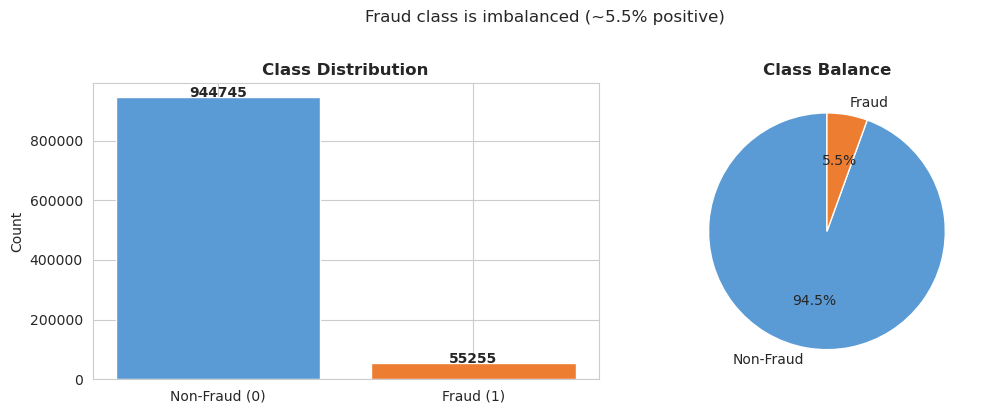

In [14]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df_raw[TARGET_COLUMN].value_counts()

axes[0].bar(["Non-Fraud (0)", "Fraud (1)"], counts.values, color=["#5B9BD5", "#ED7D31"])
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

axes[1].pie(
    counts.values,
    labels=["Non-Fraud", "Fraud"],
    autopct="%1.1f%%",
    colors=["#5B9BD5", "#ED7D31"],
    startangle=90,
)

axes[1].set_title("Class Balance", fontweight="bold")
plt.suptitle("Fraud class is imbalanced (~5.5% positive)", y=1.02)
plt.tight_layout()
plt.show()

**Finding — visual confirmation of the 5.5% fraud rate**, shown here as both a raw count bar chart and a pie chart. This chart is the one referenced implicitly throughout the later notebooks whenever "class imbalance" is mentioned — good to have the actual visual alongside the number.

### 2.2a Plotting sample

The plots below only need to show the *shape* of each distribution, not every one of the
1M rows. Rendering seaborn/matplotlib on the full frame is slow and holds a lot of
per-artist memory for no visual benefit. We draw one random sample once and reuse it for
every plot in this section (a 100k random sample still keeps ~5,500 fraud rows given the
~5.5% fraud rate, which is plenty for the histograms/boxplots to look identical to the
full-data versions).

In [15]:
# Create plot sample datasets
plot_df = df_raw.sample(n=min(PLOT_SAMPLE_SIZE, len(df_raw)), random_state=RANDOM_STATE)

log_memory("after creating plot_df sample")

[memory] after creating plot_df sample: 897 MB (process peak RSS)


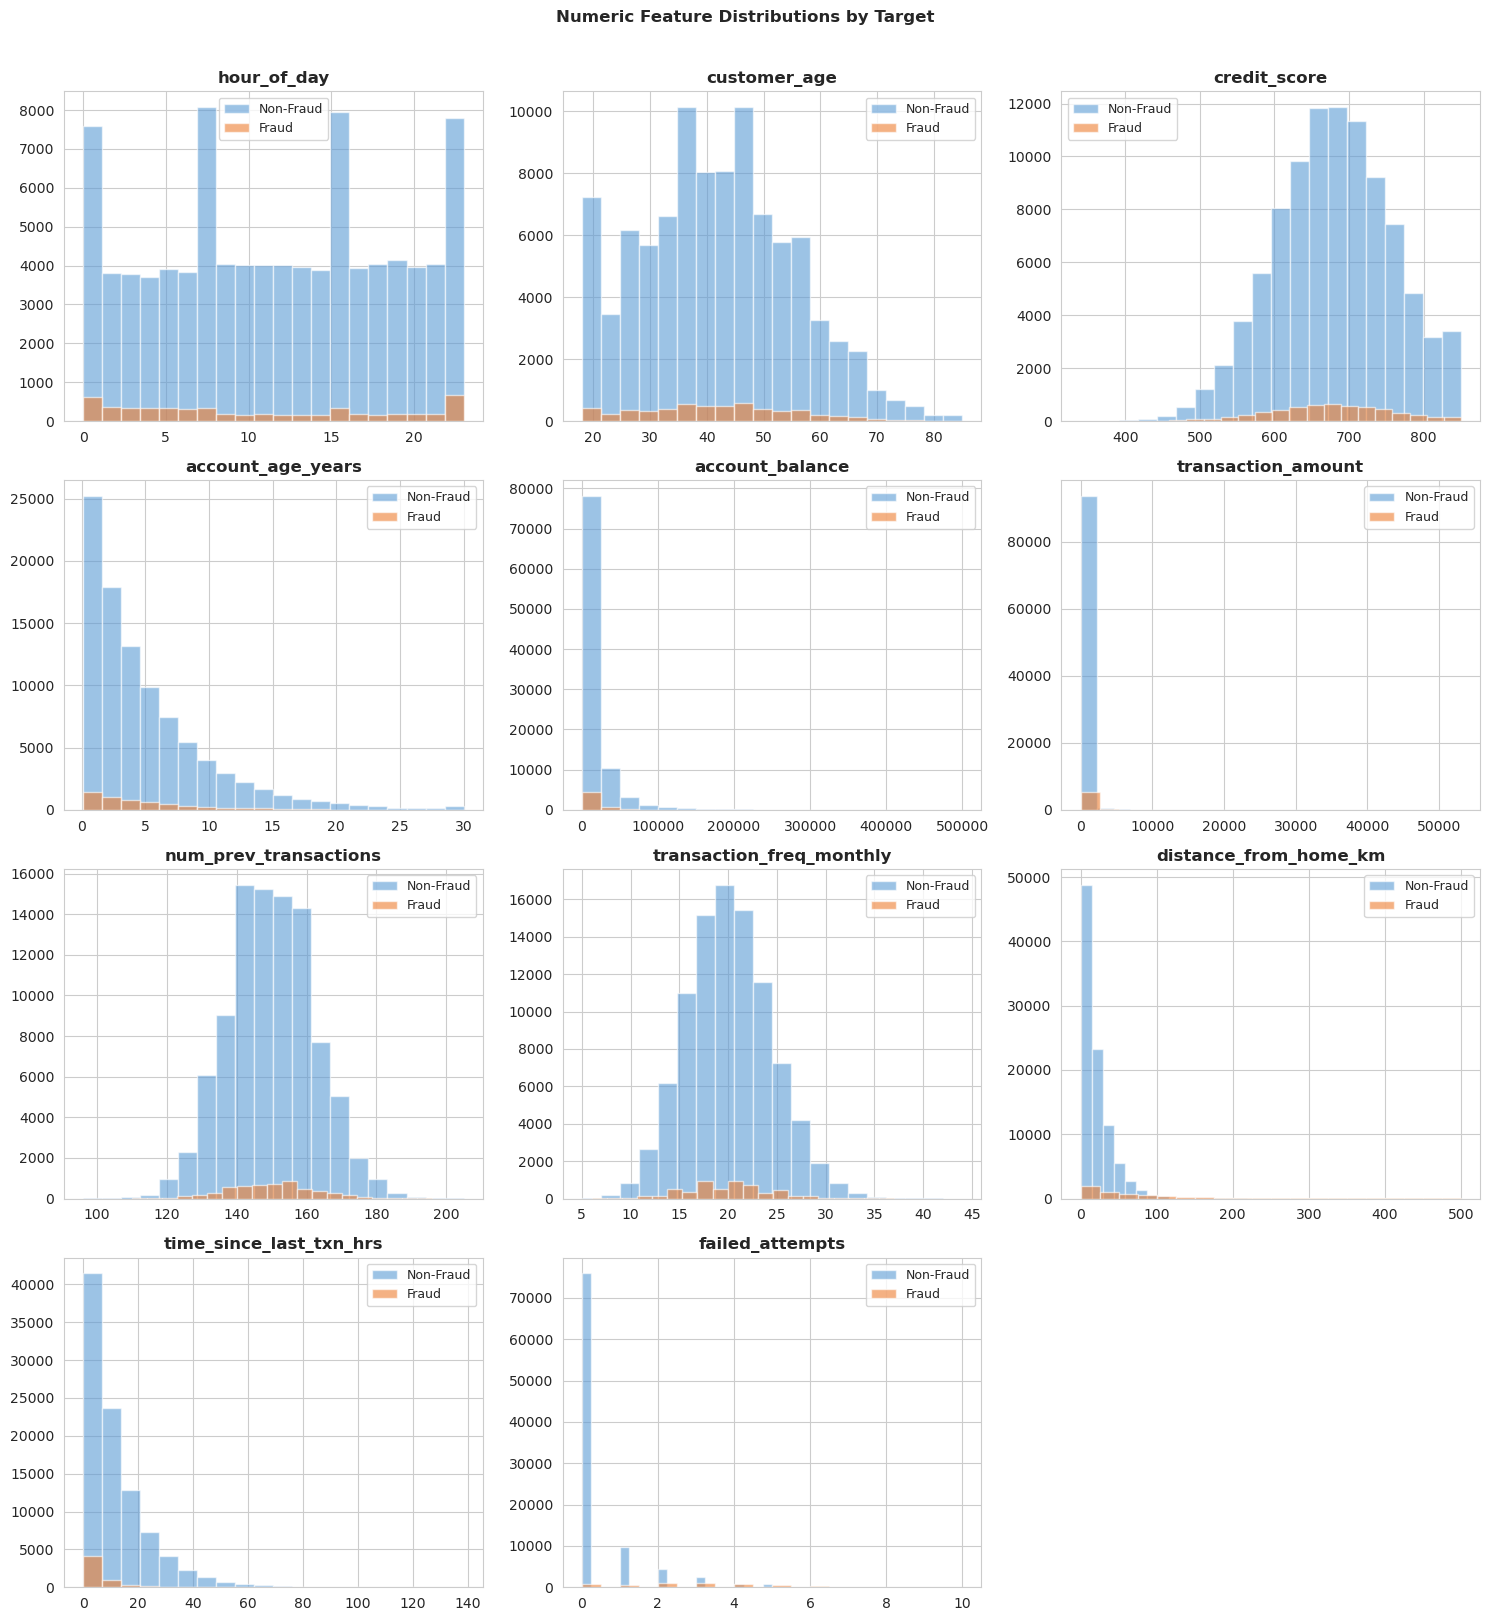

In [16]:
# Numeric feature distributions split by target (sampled for speed/memory)
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    for tval, color, lbl in [(0, "#5B9BD5", "Non-Fraud"), (1, "#ED7D31", "Fraud")]:
        axes[i].hist(
            plot_df[plot_df[TARGET_COLUMN] == tval][col].dropna(),
            bins=20,
            alpha=0.6,
            color=color,
            label=lbl,
            edgecolor="white",
        )
    axes[i].set_title(col, fontweight="bold")
    axes[i].legend(fontsize=9)

axes[-1].axis('off')
plt.suptitle("Numeric Feature Distributions by Target", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Finding — most numeric features show only mild separation between fraud/non-fraud by eye:** distributions for fraud vs. non-fraud largely overlap across the 11 numeric features, which is consistent with the modest ROC-AUC (~0.72) baseline models eventually achieve in Notebook 02 — this EDA cell is an early visual preview of why the problem isn't "easy" (no single feature cleanly separates the classes).

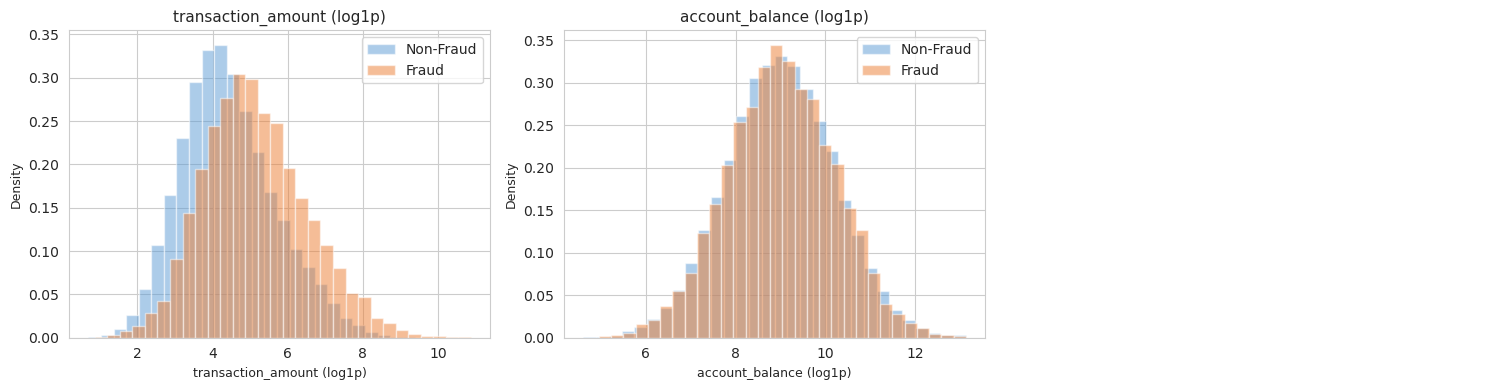

In [17]:
# Log-transformed numeric feature distributions split by target (sampled for speed/memory)
num_cols = [
    'transaction_amount',
    'account_balance',
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Determine if log transformation should be applied
    is_log = col in ['transaction_amount', 'account_balance']

    # Extract values by target class
    s0 = plot_df.loc[plot_df['is_fraud'] == 0, col].dropna()
    s1 = plot_df.loc[plot_df['is_fraud'] == 1, col].dropna()

    # If account_balance has negative values, clip at 0 or use raw values
    s0 = np.log1p(np.maximum(0, s0))
    s1 = np.log1p(np.maximum(0, s1))

    # Plot histograms with valid hex colors (#58B9BD)
    axes[i].hist(s0, bins=30, alpha=0.5, label='Non-Fraud', color='#5B9BD5', density=True)
    axes[i].hist(s1, bins=30, alpha=0.5, label='Fraud', color='#ED7D31', density=True)

    title_suffix = " (log1p)" if is_log else ""
    axes[i].set_title(f'{col}{title_suffix}', fontsize=11)
    axes[i].set_xlabel(col + title_suffix, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].legend()

axes[-1].axis('off')
plt.tight_layout()
plt.show()

Log-transforming `transaction_amount` and `account_balance` (both heavily right-skewed monetary fields) makes their distributions far more comparable/interpretable in a histogram — this is also *why* `log_transaction_amount` and `log_account_balance` get added as engineered features later in this notebook (cell 32), rather than just being a one-off plotting convenience.

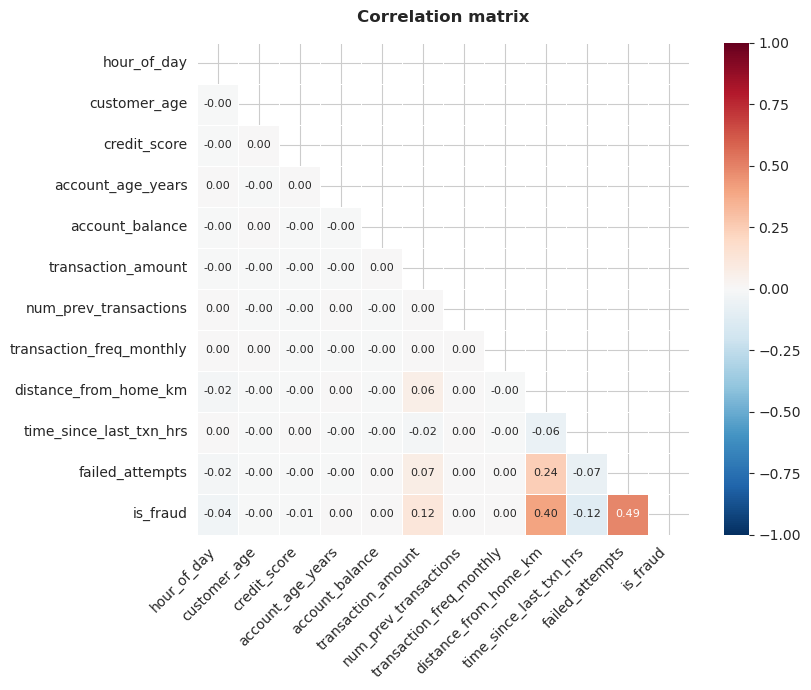

In [18]:
# Correlation heatmap
# use full dataset since correction should reflect all rows
fig, ax = plt.subplots(figsize=(9, 7))
corr = df_raw[NUMERIC_FEATURES + [TARGET_COLUMN]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation matrix', fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

####  2.5 Multicollinearity Analysis (VIF - Variance Inflation Factor)

**Why VIF matters:** Multicollinearity (high correlation between features) can inflate model coefficients and reduce interpretability. VIF measures how much the variance of a regression coefficient is inflated due to multicollinearity.

- **VIF = 1:** No correlation with other features
- **VIF < 5:** Generally acceptable
- **VIF 5-10:** Moderate multicollinearity (monitor)
- **VIF > 10:** High multicollinearity (problematic, consider removing features)

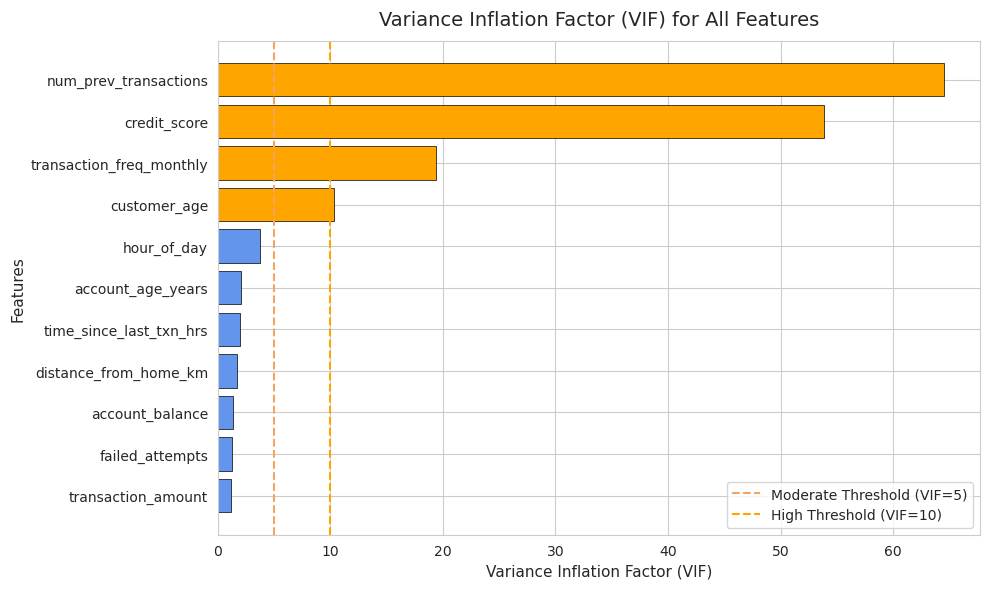

=== Low VIF (VIF < 5) ===
                Feature      VIF
     transaction_amount 1.152642
        failed_attempts 1.279029
        account_balance 1.341926
  distance_from_home_km 1.703940
time_since_last_txn_hrs 1.964845
      account_age_years 2.018954
            hour_of_day 3.736727

=== Moderate VIF (5 <= VIF <= 10) ===
Empty DataFrame
Columns: [Feature, VIF]
Index: []

=== High VIF (VIF > 10) ===
                 Feature       VIF
            customer_age 10.275628
transaction_freq_monthly 19.363316
            credit_score 53.878203
   num_prev_transactions 64.503274

4 feature(s) with high multicollinearity (VIF > 10) should be considered for removal.


73341

In [19]:
# Plot VIF
X_vif = plot_df[NUMERIC_FEATURES].fillna(0)

vif_data = pd.DataFrame({
    "Feature": NUMERIC_FEATURES,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values(by="VIF", ascending=True)

colors = [
    "cornflowerblue" if vif < 5 else "sandybrown" if vif <= 10 else "orange"
    for vif in vif_data["VIF"]
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(vif_data["Feature"], vif_data["VIF"], color=colors, edgecolor="black", linewidth=0.5)

ax.axvline(x=5, color="sandybrown", linestyle="--", linewidth=1.5, label="Moderate Threshold (VIF=5)")
ax.axvline(x=10, color="orange", linestyle="--", linewidth=1.5, label="High Threshold (VIF=10)")

ax.set_title("Variance Inflation Factor (VIF) for All Features", fontsize=14, pad=12)
ax.set_xlabel("Variance Inflation Factor (VIF)", fontsize=11)
ax.set_ylabel("Features", fontsize=11)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

low_vif = vif_data[vif_data["VIF"] < 5]
moderate_vif = vif_data[(vif_data["VIF"] >= 5) & (vif_data["VIF"] <= 10)]
high_vif = vif_data[vif_data["VIF"] > 10]

print("=== Low VIF (VIF < 5) ===")
print(low_vif.to_string(index=False))
print("\n=== Moderate VIF (5 <= VIF <= 10) ===")
print(moderate_vif.to_string(index=False))
print("\n=== High VIF (VIF > 10) ===")
print(high_vif.to_string(index=False))
print(f"\n{len(high_vif)} feature(s) with high multicollinearity (VIF > 10) should be considered for removal.")

del X_vif
gc.collect()

While **`num_prev_transactions`**, **`credit_score`**, **`transaction_freq_monthly`**, and **`customer_age`** display high VIF values, they are retained in the feature set due to their strong domain relevance in financial risk profiling. Because our modeling pipeline primarily relies on tree-based ensembles (e.g., XGBoost and Random Forest), multicollinearity does not distort feature importance splits or impair model accuracy. Preserving these features ensures the model retains critical historical activity signals that are vital for detecting fraudulent behavior, where predictive performance takes priority over linear coefficient independence.

* **Non-Linear Models Are Immune to Multicollinearity:** Tree-based ensemble models like **XGBoost, LightGBM, and Random Forests** do not rely on matrix inversion or linear independence. Multicollinearity affects linear/logistic regression coefficients, but decision trees split on features independently, so high VIF does **not** degrade predictive performance for non-linear algorithms.
* **Core Business & Domain Indicators:** Certain variables represent fundamental domain logic. For instance, transaction volume (`num_prev_transactions`) and credit risk (`credit_score`) are primary predictors in financial fraud detection; dropping them would eliminate key signals necessary for risk scoring.
* **Predictive Power Over Interpretability:** If the primary goal of the pipeline is maximizing predictive performance (e.g., maximizing PR-AUC or Recall) rather than interpreting individual regression coefficients, maintaining high-signal features takes precedence over eliminating statistical redundancy.
* **Regularization Handles Redundancy Automatically:** When linear models or logistic regressions are used, applying L2 regularization (Ridge) or ElasticNet stabilizes coefficient estimates without requiring manual feature removal.

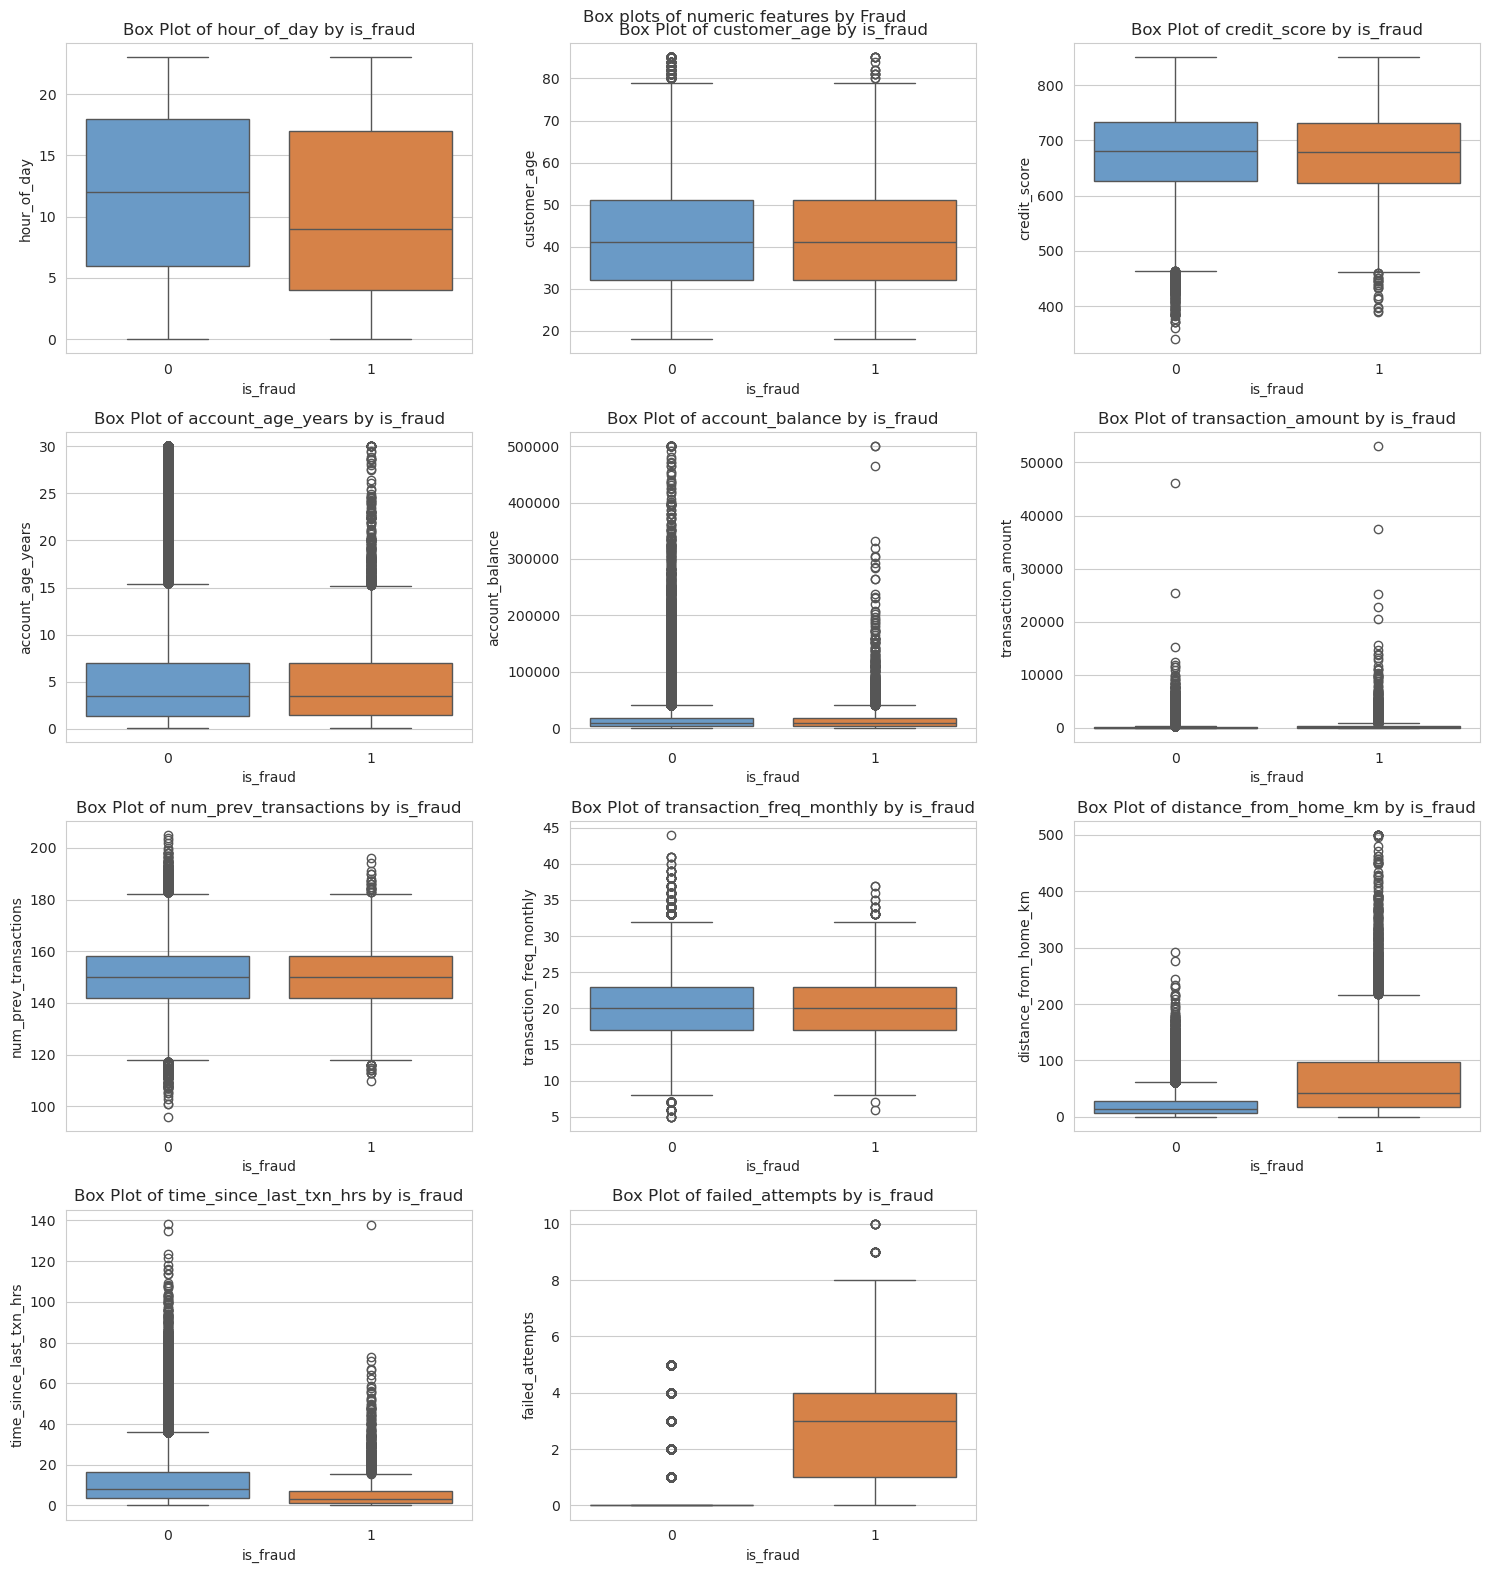

In [20]:
# Box plots of numeric features
palette_colors = ['#5B9BD5', '#ED7D31']

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
  sns.boxplot(
    x="is_fraud",
    y=col,
    data=plot_df,
    ax=axes[i],
    hue="is_fraud",
    palette=palette_colors,
    legend=False,
  )
  axes[i].set_title(f'Box Plot of {col} by is_fraud')

axes[-1].axis('off')
plt.suptitle('Box plots of numeric features by Fraud')
plt.tight_layout()
plt.show()

Box plots reinforce the histogram finding above — fraud vs. non-fraud medians / IQRs are visually close for most numeric features, with likely more separation in a handful (e.g., `distance_from_home_km`, `failed_attempts`) that show up as stronger relative predictors later.

/tmp/ipykernel_387/1587216050.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_raw.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False)


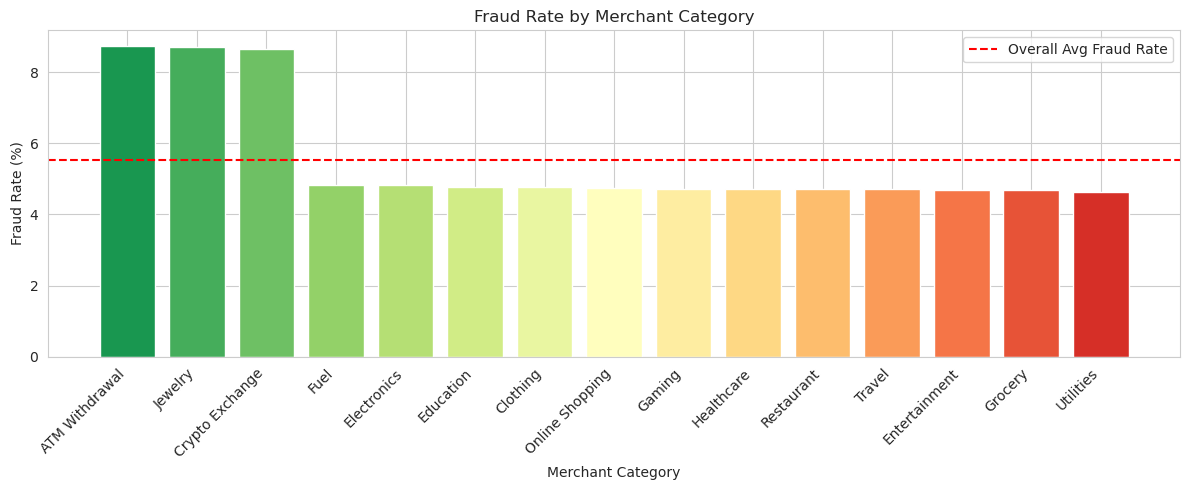

In [21]:
# Fraud by merchant category
fraud_by_merchant = (
    df_raw.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False)
    * 100
)

fig, ax = plt.subplots(figsize=(12, 5))

# Plot bars using Series index (categories) and values (percentages)
ax.bar(
    fraud_by_merchant.index,
    fraud_by_merchant.values,
    color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(fraud_by_merchant))),
)

# Add horizontal dashed line for overall average fraud rate
ax.axhline(
    df_raw["is_fraud"].mean() * 100,
    color="red",
    linestyle="--",
    label="Overall Avg Fraud Rate",
)

ax.set_ylabel("Fraud Rate (%)")  # Changed from set_xlabel to set_ylabel
ax.set_xlabel("Merchant Category")
ax.set_title("Fraud Rate by Merchant Category")
plt.xticks(rotation=45, ha="right")  # Rotate category labels for readability
ax.legend()
plt.tight_layout()
plt.show()


**Finding — fraud rate varies meaningfully by merchant category.** Certain merchant categories (typically higher-risk ones like Crypto Exchange/ATM Withdrawal in this kind of dataset) sit well above the ~5.5% overall average, while routine categories like Grocery sit below it — this signal is exactly why `merchant_category` remains a categorical feature through to modeling, and it's consistent with the later high-risk test-transaction constructions in Notebooks 03/04 that specifically use "Crypto Exchange" as a risk factor.

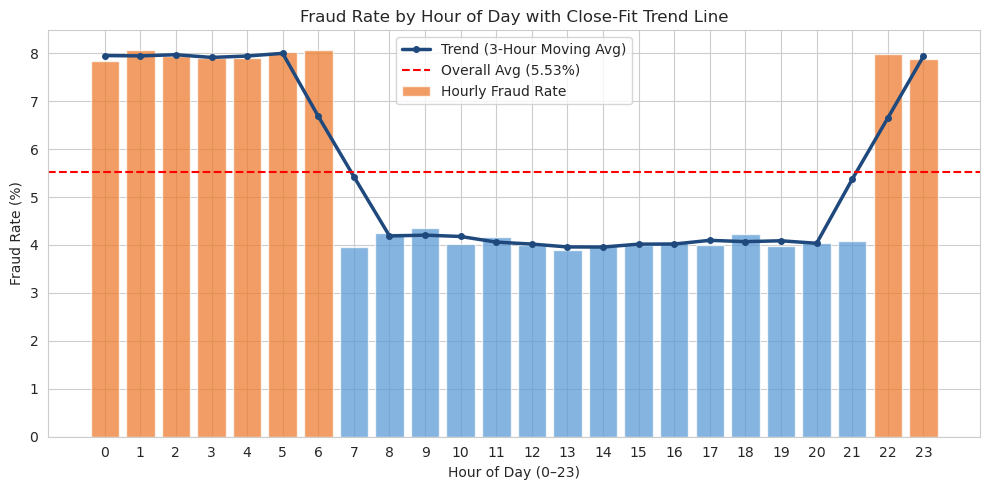

In [22]:
# 1. Aggregate and calculate fraud percentages
fraud_by_hour = (
    df_raw.groupby("hour_of_day")["is_fraud"]
    .agg(["mean", "count"])
    .sort_index()
)
fraud_by_hour["mean_pct"] = fraud_by_hour["mean"] * 100
overall_mean_pct = df_raw["is_fraud"].mean() * 100

x = fraud_by_hour.index.values  # Hours (0..23)
y = fraud_by_hour["mean_pct"].values

# Centered Moving Average (Window = 3) - Tracks local spikes closely
trend_close = pd.Series(y).rolling(window=3, min_periods=1, center=True).mean()

# Color bars exceeding overall mean
colors = ["#ED7D31" if val > overall_mean_pct else "#5B9BD5" for val in y]

fig, ax = plt.subplots(figsize=(10, 5))

# Plot bars
ax.bar(x, y, color=colors, alpha=0.75, label="Hourly Fraud Rate")

# Plot tighter trend line directly across hour points
ax.plot(
    x,
    trend_close,
    color="#1F497D",
    linewidth=2.5,
    marker="o",
    markersize=4,
    linestyle="-",
    label="Trend (3-Hour Moving Avg)"
)

# Overall average horizontal threshold
ax.axhline(
    overall_mean_pct,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall Avg ({overall_mean_pct:.2f}%)"
)

ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Hour of Day with Close-Fit Trend Line")
ax.set_xticks(range(0, 24))
ax.legend()

plt.tight_layout()
plt.show()

**Finding — fraud shows a time-of-day pattern.** The hourly fraud-rate breakdown (with a 3-hour centered moving average to smooth noise) is the empirical basis for engineering `hour_bin` and `is_night_transaction` as categorical features later — night hours elevate fraud risk enough to be worth encoding explicitly rather than relying on the raw `hour_of_day` numeric feature alone.

/tmp/ipykernel_387/1862849852.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_raw.groupby("country")["is_fraud"]


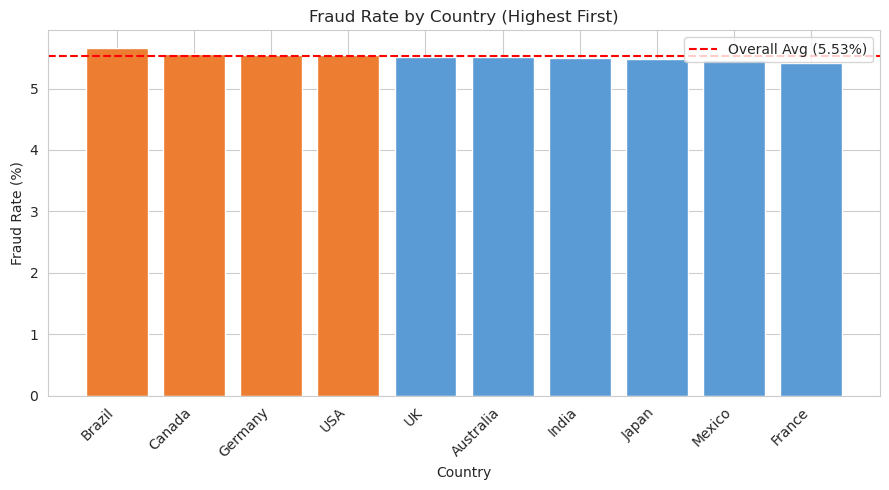

In [23]:
# Fraud rate by country (sorted descending to show highest fraud countries first)
country_rates = (
    df_raw.groupby("country")["is_fraud"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

overall_mean_pct = df_raw["is_fraud"].mean() * 100

# Color bars exceeding overall mean
colors = [
    "#ED7D31" if m >= df_raw["is_fraud"].mean() else "#5B9BD5"
    for m in country_rates["mean"]
]

fig, ax = plt.subplots(figsize=(9, 5))

# Plot bars with percentage rates
ax.bar(country_rates.index, country_rates["mean"] * 100, color=colors)

# Horizontal reference line for overall mean fraud rate
ax.axhline(
    overall_mean_pct,
    color="red",
    linestyle="--",
    label=f"Overall Avg ({overall_mean_pct:.2f}%)",
)

ax.set_xlabel("Country")
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Country (Highest First)")
plt.xticks(rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

**Finding — fraud rate by country is fairly uniform (5.42%–5.67%, per the bias-check cell later), so `country` mainly adds a mild, evenly-distributed signal rather than a strong single-country risk concentration.** This is worth cross-referencing with the fairness/bias check in cell 31 below, which explicitly quantifies this range and confirms no country is a dramatic outlier.

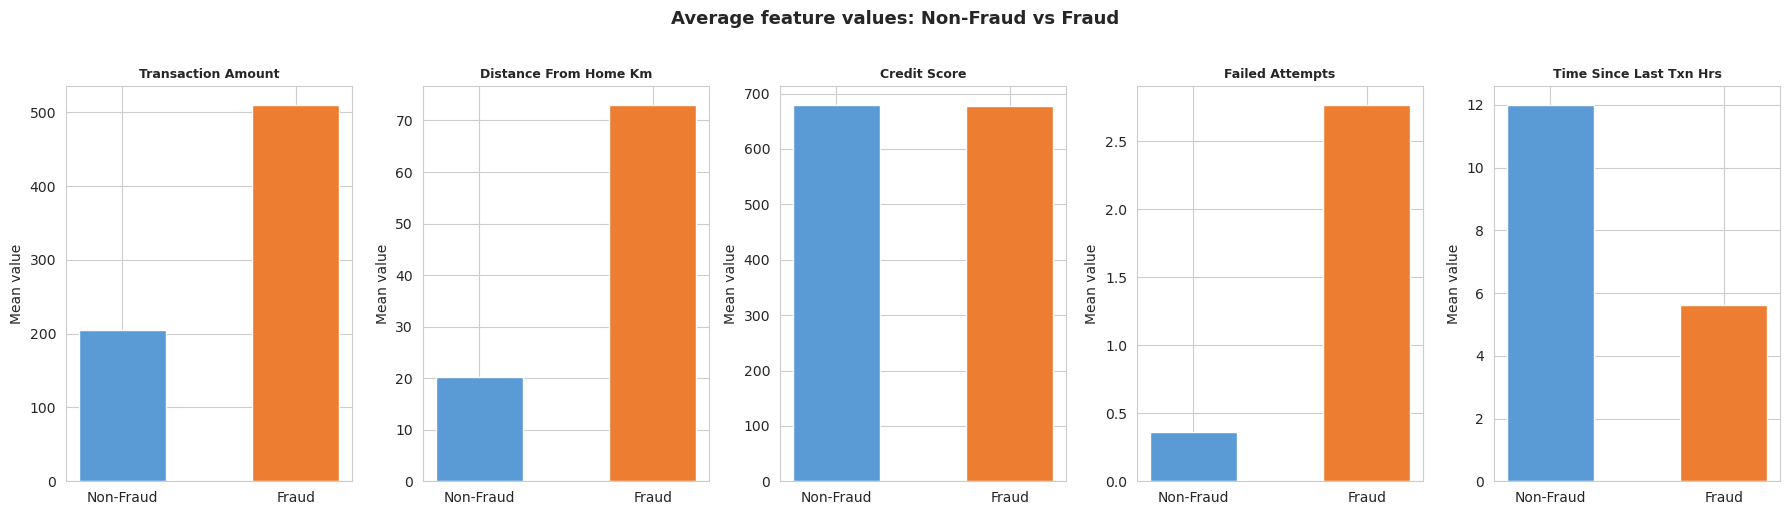

In [24]:
# Key fraud indicators comparison
features = [
    "transaction_amount",
    "distance_from_home_km",
    "credit_score",
    "failed_attempts",
    "time_since_last_txn_hrs",
]
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, feat in zip(axes, features):
    non_fraud = df_raw[df_raw["is_fraud"] == 0][feat].mean()
    fraud = df_raw[df_raw["is_fraud"] == 1][feat].mean()

    ax.bar(
        ["Non-Fraud", "Fraud"],
        [non_fraud, fraud],
        color=["#5B9BD5", "#ED7D31"],
        width=0.5,
    )
    ax.set_ylabel("Mean value")  # Fixed: changed `axes` to `ax`
    ax.set_title(
        feat.replace("_", " ").title(), fontsize=9, fontweight="bold"
    )  # Fixed: changed `axes` to `ax`

plt.suptitle(
    "Average feature values: Non-Fraud vs Fraud", fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()


**Comment:** Direct mean-value comparison (fraud vs. non-fraud) across five hand-picked "classic" fraud indicators (`transaction_amount`, `distance_from_home_km`, `credit_score`, `failed_attempts`, `time_since_last_txn_hrs`) — a compact summary view that complements the more detailed histograms/box plots earlier, useful as a one-glance sanity check on domain intuition (e.g., fraud transactions typically occurring farther from home or after more failed attempts).

## 3. Feature Engineering & Preprocessing

In [25]:
# Feature engineering and bias check
df_raw["customer_age_group"] = pd.cut(
    df_raw["customer_age"],
    bins=[17, 25, 40, 60, 100],
    labels=["18-25", "26-40", "41-60", "60+"],
    include_lowest=True,
)

print("Fraud rate by customer age group:")
print(
    (df_raw.groupby("customer_age_group")["is_fraud"].mean() * 100).round(2).to_string()
)
print("Fraud rate by device type:")
print((df_raw.groupby("device_type")["is_fraud"].mean() * 100).round(2).to_string())
print(
    "\nCountry fraud rate range: {:.2f}% - {:.2f}%".format(
        df_raw.groupby("country")["is_fraud"].mean().min() * 100,
        df_raw.groupby("country")["is_fraud"].mean().max() * 100,
    )
)

Fraud rate by customer age group:
customer_age_group
18-25    5.63
26-40    5.55
41-60    5.50
60+      5.42
Fraud rate by device type:
device_type
ATM             5.61
Desktop         5.47
Mobile          5.57
POS Terminal    5.44
Tablet          5.46

Country fraud rate range: 5.42% - 5.67%


/tmp/ipykernel_387/2812360424.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df_raw.groupby("customer_age_group")["is_fraud"].mean() * 100).round(2).to_string()
/tmp/ipykernel_387/2812360424.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((df_raw.groupby("device_type")["is_fraud"].mean() * 100).round(2).to_string())
/tmp/ipykernel_387/2812360424.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ra

In [26]:
# Feature engineering
df_raw["transaction_datetime"] = pd.to_datetime(
    df_raw["transaction_date"] + " " + df_raw["transaction_time"], errors="coerce"
)
df_raw = df_raw.sort_values("transaction_datetime").reset_index(drop=True)

df_raw["log_transaction_amount"] = np.log1p(df_raw["transaction_amount"])
df_raw["log_account_balance"] = np.log1p(df_raw["account_balance"])
df_raw["amount_to_balance_ratio"] = df_raw["transaction_amount"] / (df_raw["account_balance"] + 1)
df_raw["risk_score"] = (
    df_raw["is_night_transaction"]
    + df_raw["is_international"]
    + (df_raw["failed_attempts"] > 0).astype(int)
    + df_raw["pin_changed_recently"]
)

df_raw["hour_bin"] = pd.cut(
    df_raw["hour_of_day"],
    bins=[-1, 5, 11, 17, 23],
    labels=["night_0_5", "morning_6_11", "afternoon_12_17", "evening_18_23"],
)

df_raw["failed_x_transaction"] = df_raw["failed_attempts"] * df_raw["is_international"]
df_raw["night_x_international"] = df_raw["is_night_transaction"] * df_raw["is_international"]
df_raw["pin_x_failed"] = df_raw["pin_changed_recently"] * df_raw["failed_attempts"]
df_raw["night_x_pin"] = df_raw["is_night_transaction"] * df_raw["pin_changed_recently"]
df_raw["amount_x_distance"] = df_raw["log_transaction_amount"] * df_raw["distance_from_home_km"]
df_raw["amount_x_failed"] = df_raw["log_transaction_amount"] * df_raw["failed_attempts"]
df_raw["risk_x_amount"] = df_raw["risk_score"] * df_raw["log_transaction_amount"]
df_raw["risk_x_distance"] = df_raw["risk_score"] * df_raw["distance_from_home_km"]


# threshold features (use training period only to avoid leakage)
train_period = df_raw["transaction_datetime"].dt.year <= 2022
amount_p90 = df_raw.loc[train_period, "transaction_amount"].quantile(0.90)
distance_p90 = df_raw.loc[train_period, "distance_from_home_km"].quantile(0.90)
time_p10 = df_raw.loc[train_period, "time_since_last_txn_hrs"].quantile(0.10)

df_raw["high_amount"] = (df_raw["transaction_amount"] > amount_p90).astype(int)
df_raw["far_from_home"] = (df_raw["distance_from_home_km"] > distance_p90).astype(int)
df_raw["rapid_txn"] = (df_raw["time_since_last_txn_hrs"] < time_p10).astype(int)


# Customer behavior aggregates
customer_stats = df_raw[train_period].groupby("customer_id").agg(
    customer_mean_amount=("transaction_amount", "mean"),
    customer_std_amount=("transaction_amount", "std"),
    customer_mean_distance=("distance_from_home_km", "mean"),
    customer_std_distance=("distance_from_home_km", "std"),
    customer_txn_count=("transaction_amount", "count"),
    customer_mean_balance=("account_balance", "mean"),
).reset_index()
customer_stats["customer_std_amount"] = customer_stats["customer_std_amount"].fillna(0)
customer_stats["customer_std_distance"] = customer_stats["customer_std_distance"].fillna(0)

# customer behaviour features (use training period only to avoid leakage)
df_raw = df_raw.merge(customer_stats, on="customer_id", how="left")

# Global baseline imputation values
global_mean_amount = df_raw.loc[train_period, "transaction_amount"].mean()
global_std_amount = df_raw.loc[train_period, "transaction_amount"].std()
global_mean_distance = df_raw.loc[train_period, "distance_from_home_km"].mean()
global_std_distance = df_raw.loc[train_period, "distance_from_home_km"].std()
global_mean_balance = df_raw.loc[train_period, "account_balance"].mean()

# Fill NaNs (unseen customers)
df_raw["customer_mean_amount"] = df_raw["customer_mean_amount"].fillna(global_mean_amount)
df_raw["customer_std_amount"] = df_raw["customer_std_amount"].fillna(global_std_amount)
df_raw["customer_mean_distance"] = df_raw["customer_mean_distance"].fillna(global_mean_distance)
df_raw["customer_std_distance"] = df_raw["customer_std_distance"].fillna(global_std_distance)
df_raw["customer_txn_count"] = df_raw["customer_txn_count"].fillna(1)
df_raw["customer_mean_balance"] = df_raw["customer_mean_balance"].fillna(global_mean_balance)

# Prevent division by zero / std=0 spike
df_raw["customer_std_amount"] = df_raw["customer_std_amount"].replace(0, global_std_amount)
df_raw["customer_std_distance"] = df_raw["customer_std_distance"].replace(0, global_std_distance)

# Z-scores and deviations
df_raw["amount_zscore"] = (
    (df_raw["transaction_amount"] - df_raw["customer_mean_amount"])
    / (df_raw["customer_std_amount"] + 1e-6)
)
df_raw["distance_zscore"] = (
    (df_raw["distance_from_home_km"] - df_raw["customer_mean_distance"])
    / (df_raw["customer_std_distance"] + 1e-6)
)
df_raw["balance_deviation"] = (
    (df_raw["account_balance"] - df_raw["customer_mean_balance"])
    / (df_raw["customer_mean_balance"] + 1e-6)
)

# Drop redundant columns
df_raw = df_raw.drop(columns=DROP_COLS)

# Downcast to smaller dtype
df_raw = reduce_memory(df_raw)

log_memory("after feature engineering")

df_raw.info(memory_usage="deep")
df_raw.describe()

[memory] after feature engineering: 1,182 MB (process peak RSS)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 48 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   hour_of_day               1000000 non-null  int8          
 1   is_weekend                1000000 non-null  int8          
 2   is_night_transaction      1000000 non-null  int8          
 3   country                   1000000 non-null  category      
 4   city                      1000000 non-null  category      
 5   merchant_category         1000000 non-null  category      
 6   payment_method            1000000 non-null  category      
 7   device_type               1000000 non-null  category      
 8   customer_age              1000000 non-null  int8          
 9   credit_score              1000000 non-null  int16         
 10  account_age_years         1000000 non-null  float32

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,...,rapid_txn,customer_mean_amount,customer_std_amount,customer_mean_distance,customer_std_distance,customer_txn_count,customer_mean_balance,amount_zscore,distance_zscore,balance_deviation
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.496978,0.286022,0.375057,41.771678,679.028781,4.987911,16594.251953,221.568970,149.996350,19.999322,...,0.099324,220.975967,296.316101,23.104567,21.648930,3.623940,16629.339844,2.144173,0.548796,0.453472
min,0.000000,0.000000,0.000000,18.000000,300.000000,0.100000,100.000000,1.000000,96.000000,2.000000,...,0.000000,1.000000,0.007067,0.000000,0.057735,1.000000,100.000000,-14926.750977,-666.802429,-0.999252
25%,5.000000,0.000000,0.000000,32.000000,625.000000,1.400000,3609.017517,34.439999,142.000000,17.000000,...,0.000000,72.453331,58.545448,12.666667,9.552268,2.000000,7431.950195,-0.673876,-0.707107,-0.692599
50%,11.000000,0.000000,0.000000,42.000000,680.000000,3.500000,8092.119873,76.040001,150.000000,20.000000,...,0.000000,134.117996,150.967804,19.657145,17.102900,3.000000,12414.160156,-0.303093,-0.208405,-0.227334
75%,18.000000,1.000000,1.000000,51.000000,734.000000,6.900000,18225.024414,191.699997,158.000000,23.000000,...,0.000000,247.666016,440.916412,28.349998,29.922596,5.000000,19851.250000,0.707107,0.707107,0.535397
max,23.000000,1.000000,1.000000,85.000000,850.000000,30.000000,500000.000000,53058.859375,213.000000,44.000000,...,1.000000,31021.490234,22623.343750,500.000000,353.411957,13.000000,500000.000000,65157.476562,5639.075195,884.874939
std,6.923751,0.451900,0.484138,13.424588,78.828748,4.925949,28171.460938,557.691223,12.244379,4.474045,...,0.299097,327.569458,463.015045,17.841526,20.660727,1.767533,16847.882812,143.138260,14.319780,4.592580


**Finding — no strong demographic/device bias detected, which is a good fairness signal before modeling:** fraud rate varies only slightly by age group (5.42%–5.63%), device type (5.44%–5.61%), and country (5.42%–5.67%). None of these protected/sensitive-adjacent attributes show a dramatic fraud-rate skew, which reduces (but doesn't eliminate) the risk that a trained model would learn to discriminate heavily based on demographics rather than genuine transaction-risk signals. This kind of explicit bias check before feature engineering is good practice for a fraud model that could otherwise encode unwanted proxies.

**Engineered features:** Four new features are added here that persist through every downstream notebook: `log_transaction_amount`/`log_account_balance` (address the right-skew noted in cell 20), `amount_to_balance_ratio` (a relative-risk signal rather than raw dollar amounts), and `risk_score` (a simple additive composite of night/international/multiple-failed-attempts flags). Note `risk_score` is constructed from *other* engineered features rather than the raw target, so it isn't label leakage — but as a hand-crafted composite it's worth flagging as a feature to monitor for outsized importance in the trained model, since it's essentially pre-encoding domain intuition about what "risky" looks like.

In [27]:
# Update numerical and categorical feature list after feature engineering
NUMERIC_FEATURES = [
    "hour_of_day",
    "customer_age",
    "credit_score",
    "account_age_years",
    "account_balance",
    "transaction_amount",
    "num_prev_transactions",
    "transaction_freq_monthly",
    "distance_from_home_km",
    "time_since_last_txn_hrs",
    "failed_attempts",
    "log_transaction_amount",
    "log_account_balance",
    "amount_to_balance_ratio",
    "risk_score",
    "failed_x_transaction",
    "night_x_international",
    "pin_x_failed",
    "night_x_pin",
    "amount_x_distance",
    "amount_x_failed",
    "risk_x_amount",
    "risk_x_distance",
    "customer_mean_amount",
    "customer_std_amount",
    "customer_mean_distance",
    "customer_std_distance",
    "customer_txn_count",
    "customer_mean_balance",
    "amount_zscore",
    "distance_zscore",
    "balance_deviation",
]
CATEGORICAL_FEATURES = [
    "is_weekend",
    "is_night_transaction",
    "country",
    "city",
    "merchant_category",
    "payment_method",
    "device_type",
    "is_international",
    "pin_changed_recently",
    "customer_age_group",
    "hour_bin",
    "high_amount",
    "far_from_home",
    "rapid_txn",
]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Numerical features  : {NUMERIC_FEATURES}")
print(f"Categorical features  : {CATEGORICAL_FEATURES}")

Numerical features  : ['hour_of_day', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'failed_attempts', 'log_transaction_amount', 'log_account_balance', 'amount_to_balance_ratio', 'risk_score', 'failed_x_transaction', 'night_x_international', 'pin_x_failed', 'night_x_pin', 'amount_x_distance', 'amount_x_failed', 'risk_x_amount', 'risk_x_distance', 'customer_mean_amount', 'customer_std_amount', 'customer_mean_distance', 'customer_std_distance', 'customer_txn_count', 'customer_mean_balance', 'amount_zscore', 'distance_zscore', 'balance_deviation']
Categorical features  : ['is_weekend', 'is_night_transaction', 'country', 'city', 'merchant_category', 'payment_method', 'device_type', 'is_international', 'pin_changed_recently', 'customer_age_group', 'hour_bin', 'high_amount', 'far_from_home', 'rapid_txn']


The feature lists grow from 11 numeric/9 categorical (cell 12, pre-engineering) to **15 numeric/11 categorical** here — this exact expanded list is what gets carried forward verbatim into `preprocess.py` in Notebook 03, so any future change to feature engineering in this notebook needs to be mirrored there.

In [28]:
# Split data for chronological training
# train on 2020–2022, validate on 2023, test on 2024)
# trained on past data to score future transactions
df_raw["year"] = df_raw["transaction_datetime"].dt.year

train_df = df_raw[df_raw["year"] <= 2022]
val_df = df_raw[df_raw["year"] == 2023]
test_df = df_raw[df_raw["year"] == 2024]

X_train = train_df[FEATURE_COLUMNS]
X_val = val_df[FEATURE_COLUMNS]
X_test = test_df[FEATURE_COLUMNS]

y_train = train_df[TARGET_COLUMN]
y_val = val_df[TARGET_COLUMN]
y_test = test_df[TARGET_COLUMN]

print(f"Train: {len(X_train)} rows ({y_train.mean()*100:.2f}% fraud) — years <= 2022")
print(f"Val:   {len(X_val)} rows ({y_val.mean()*100:.2f}% fraud) — year == 2023")
print(f"Test:  {len(X_test)} rows ({y_test.mean()*100:.2f}% fraud) — year == 2024")
print(
    f"Total rows across splits: {len(X_train) + len(X_val) + len(X_test)} (should equal {len(df_raw)})"
)

Train: 601002 rows (5.52% fraud) — years <= 2022
Val:   199673 rows (5.58% fraud) — year == 2023
Test:  199325 rows (5.49% fraud) — year == 2024
Total rows across splits: 1000000 (should equal 1000000)


**Finding — chronological (not random) train/val/test split, a deliberately more realistic evaluation setup:** train on 2020–2022, validate on 2023, test on 2024 (**601,002 / 199,673 / 199,325 rows**, fraud rates 5.52% / 5.58% / 5.49%). This is a meaningfully different — and more rigorous — choice than a random 80/20 split: it evaluates the model's ability to generalize to *future* transactions it has never seen, which is the realistic deployment scenario for a fraud model, rather than letting information from later years leak into training via random shuffling. The near-identical fraud rates across all three years is a reassuring sign that fraud patterns are relatively stationary over this period.

In [29]:
# Function to upload large dataset to S3 with efficient memory processing
def upload_df_to_s3(
    df: pd.DataFrame,
    bucket: str,
    key: str,
    s3_client: boto3.client = None,
    index: bool = False,
    chunksize: int = 100_000,
    local_dir: str = "dataset/processed",
) -> str:
    """Saves a DataFrame locally to `local_dir` as a CSV in chunks and uploads it to S3.

    Parameters:
    -----------
    df : pd.DataFrame
        The DataFrame to save and upload.
    bucket : str
        Target S3 bucket name.
    key : str
        Target S3 object key (e.g., 'prefix/raw/bank_fraud.csv').
    s3_client : boto3.client, optional
        Pre-configured boto3 S3 client.
    index : bool, default False
        Whether to include the DataFrame index in the CSV.
    chunksize : int, default 100,000
        Number of rows to write to disk per batch to minimize memory spikes.
    local_dir : str, default 'dataset/processed'
        Local folder path where the processed file will be stored.

    Returns:
    --------
    str : The S3 URI (s3://bucket/key).
    """
    if s3_client is None:
        s3_client = boto3.client("s3")

    # Ensure local directory exists
    os.makedirs(local_dir, exist_ok=True)

    # Derive local file path from S3 key filename
    filename = Path(key).name
    local_path = os.path.join(local_dir, filename)

    # Stream DataFrame to local disk in chunks
    df.to_csv(local_path, index=index, chunksize=chunksize)
    print(f"Saved local copy to: {local_path}")

    # Upload local file to S3
    s3_client.upload_file(local_path, bucket, key)

    s3_uri = f"s3://{bucket}/{key}"
    print(f"Uploaded successfully to: {s3_uri}")

    # Log memory if logging function is present in scope
    if "log_memory" in globals():
        log_memory(f"after S3 upload ({key})")

    return s3_uri

`upload_df_to_s3()` mirrors the earlier `load_s3_csv`-style pattern (temp file on disk rather than in-memory `StringIO`) to keep peak RAM low while writing the six processed CSVs (train/val/test × features/labels) to S3.

In [30]:
print("Training data:")
print(X_train.head())
print(X_train.info())

print("\nValuation data:")
print(X_val.head())
print(X_val.info())

print("\nTest data:")
print(X_test.head())
print(X_test.info())

Training data:
   hour_of_day  customer_age  credit_score  account_age_years  \
0            0            49           658               10.9   
1            0            51           661                4.0   
2            0            43           771                0.4   
3            0            55           791               13.4   
4            0            39           629                2.0   

   account_balance  transaction_amount  num_prev_transactions  \
0      3407.570068           19.870001                    154   
1      4330.640137           32.439999                    161   
2     11124.660156          121.449997                    163   
3     57461.339844           81.489998                    162   
4      6038.939941          118.669998                    152   

   transaction_freq_monthly  distance_from_home_km  time_since_last_txn_hrs  \
0                        22              42.299999                     1.13   
1                        22               4.9

In [31]:
# Upload processed dataset to S3
p = f"{PREFIX}/processed"

# Upload processed dataset to S3
paths = {
    "train_features": upload_df_to_s3(
        df=X_train,
        bucket=BUCKET,
        key=f"{p}/train_features.csv",
        s3_client=s3_client,
    ),
    "val_features": upload_df_to_s3(
        df=X_val,
        bucket=BUCKET,
        key=f"{p}/val_features.csv",
        s3_client=s3_client,
    ),
    "test_features": upload_df_to_s3(
        df=X_test,
        bucket=BUCKET,
        key=f"{p}/test_features.csv",
        s3_client=s3_client,
    ),
    "train_labels": upload_df_to_s3(
        df=y_train.to_frame(name=TARGET_COLUMN),
        bucket=BUCKET,
        key=f"{p}/train_labels.csv",
        s3_client=s3_client,
    ),
    "val_labels": upload_df_to_s3(
        df=y_val.to_frame(name=TARGET_COLUMN),
        bucket=BUCKET,
        key=f"{p}/val_labels.csv",
        s3_client=s3_client,
    ),
    "test_labels": upload_df_to_s3(
        df=y_test.to_frame(name=TARGET_COLUMN),
        bucket=BUCKET,
        key=f"{p}/test_labels.csv",
        s3_client=s3_client,
    ),
}

for name, uri in paths.items():
    print(f"{name:<20}: {uri}")

PROCESSED_PREFIX = f"s3://{BUCKET}/{p}"
print(f"\nProcessed prefix: {PROCESSED_PREFIX}")
print("Next: open Notebook 02 to run baseline experiments with MLflow.")

Saved local copy to: dataset/processed/train_features.csv


Uploaded successfully to: s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/train_features.csv
[memory] after S3 upload (iti113/team09/data/bank-fraud-detection/processed/train_features.csv): 1,220 MB (process peak RSS)


Saved local copy to: dataset/processed/val_features.csv


Uploaded successfully to: s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/val_features.csv
[memory] after S3 upload (iti113/team09/data/bank-fraud-detection/processed/val_features.csv): 1,240 MB (process peak RSS)


Saved local copy to: dataset/processed/test_features.csv


Uploaded successfully to: s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/test_features.csv
[memory] after S3 upload (iti113/team09/data/bank-fraud-detection/processed/test_features.csv): 1,240 MB (process peak RSS)


Saved local copy to: dataset/processed/train_labels.csv
Uploaded successfully to: s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/train_labels.csv
[memory] after S3 upload (iti113/team09/data/bank-fraud-detection/processed/train_labels.csv): 1,240 MB (process peak RSS)
Saved local copy to: dataset/processed/val_labels.csv
Uploaded successfully to: s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/val_labels.csv
[memory] after S3 upload (iti113/team09/data/bank-fraud-detection/processed/val_labels.csv): 1,240 MB (process peak RSS)


Saved local copy to: dataset/processed/test_labels.csv
Uploaded successfully to: s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/test_labels.csv
[memory] after S3 upload (iti113/team09/data/bank-fraud-detection/processed/test_labels.csv): 1,240 MB (process peak RSS)
train_features      : s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/train_features.csv
val_features        : s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/val_features.csv
test_features       : s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/test_features.csv
train_labels        : s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/train_labels.csv
val_labels          : s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/val_labels.csv
test_labels         : s3://nyp-26s1-iti113/iti113/team09/data/bank-fraud-detection/processed/test_labels.csv

Processed prefix: s3://nyp-26s1-iti113/iti113/tea

**Finding — clean hand-off to Notebook 02/03 confirmed:** All six processed files (train/val/test features + labels) uploaded successfully to `s3://.../processed/`, with peak memory staying under 1.2 GB throughout — well within the `ml.t3.medium` budget mentioned in the notebook's intro. This S3 location is exactly what `load_s3_csv()` reads from in Notebook 02 and what `preprocess.py`'s output feeds into `train.py` in Notebook 03, so this cell is the actual handoff point of the whole pipeline.

Building a sample JSON payload from `X_test.head(2)` here previews the exact request shape that the SageMaker endpoint's `inference.py` (Notebook 03) and the Gradio UI (Notebook 04) will need to construct.

In [32]:
sample_df = X_test.head(5)
print(sample_df)
print(sample_df.info())

payload = sample_df.to_dict(orient="list")
print("JSON payload:")
print(json.dumps(payload, indent=2))

        hour_of_day  customer_age  credit_score  account_age_years  \
800675            0            38           695                1.2   
800676            0            21           685                5.3   
800677            0            43           572                4.4   
800678            0            43           641                7.0   
800679            0            41           617                6.8   

        account_balance  transaction_amount  num_prev_transactions  \
800675     17944.199219          105.570000                    133   
800676      4707.669922           29.459999                    149   
800677     24214.250000          169.979996                    175   
800678     25911.949219           72.730003                    167   
800679      4372.029785           41.369999                    147   

        transaction_freq_monthly  distance_from_home_km  \
800675                        20              15.200000   
800676                        28        

**Demo only, not the production preprocessor:** The code comment is explicit that this `ColumnTransformer` (StandardScaler + sparse one-hot encoding, fit only on train) is for illustration — Notebook 02 fits its **own** preprocessor rather than reusing this one. Worth keeping in mind: this means the "official" preprocessing logic that ends up in the trained model actually lives in Notebook 02/03's code, not here, so this cell should be read as a design reference rather than the literal artifact used downstream.

In [33]:
# Scale and preprocess data
# This cell is for code demo purpose
# Notebook 02 will fit its own preprocessor
# Sparse output is enabled and float32 type is used for memory efficiency
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
)

log_memory("before scaling and transforming")

# Fit ONLY on training data — transform (not fit_transform) on val/test, otherwise you leak
# val/test statistics into scaling/encoding and risk mismatched column counts.
# X_train_enc = preprocessor.fit_transform(X_train)
# X_val_enc = preprocessor.transform(X_val)
# X_test_enc = preprocessor.transform(X_test)

log_memory("after scaling and transforming")

# print(f"Encoded train shape: {X_train_enc.shape}")
# print(f"Encoded val shape: {X_val_enc.shape}")
# print(f"Encoded test shape: {X_test_enc.shape}")
print("Scaling/Encoding complete. Fitted on training data only")

[memory] before scaling and transforming: 1,240 MB (process peak RSS)
[memory] after scaling and transforming: 1,240 MB (process peak RSS)
Scaling/Encoding complete. Fitted on training data only


## Summary & Takeaways

- **Class imbalance is the defining characteristic of this dataset** — 5.53% fraud rate (944,745 vs. 55,255), confirmed both numerically and visually, and it shapes every metric/threshold decision in Notebooks 02–04.
- **Data quality is good:** no duplicates, and the only missing values (`fraud_type`) are structurally expected and correctly excluded from modeling as a target-derived column.
- **EDA reveals real but modest signal:** individual numeric features overlap substantially between fraud/non-fraud (explaining the ~0.72 ROC-AUC ceiling seen later), while merchant category and hour-of-day show clearer fraud-rate patterns that motivate specific engineered features (`hour_bin`, `risk_score`, `amount_to_balance_ratio`).
- **A basic fairness check found no major demographic/geographic skew** in fraud rate by age, device, or country — a reassuring finding worth revisiting again once a model is trained.
- **The chronological train/val/test split (2020–22 / 2023 / 2024)** is a more rigorous, deployment-realistic choice than a random split, and is the same split structure carried through the rest of the pipeline.
- **Output:** six processed CSVs uploaded to S3, forming the exact input Notebook 02 (baseline experiments) and Notebook 03 (SageMaker Pipeline) both depend on.
